--- Running Pipeline for ERing ---
Đã tải thành công: Train (30 mẫu), Test (270 mẫu)
Training standard k-NN (Euclidean)...
--- Đánh giá mô hình: k-NN (Euc) ---
Accuracy : 0.9444
Precision: 0.9465
Recall   : 0.9444
F1-Score : 0.9447



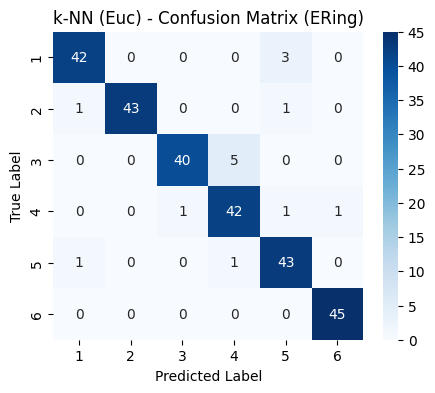

Training k-NN with DTW...
--- Đánh giá mô hình: k-NN (DTW) ---
Accuracy : 0.9148
Precision: 0.9260
Recall   : 0.9148
F1-Score : 0.9155



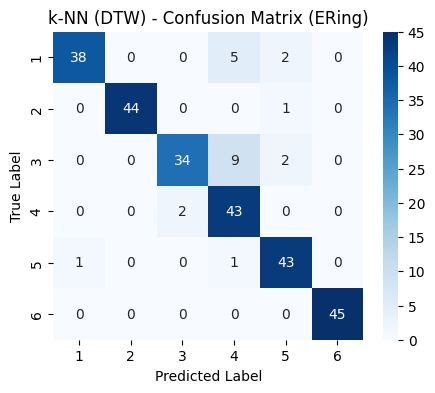

Training LSTM...


epoch,train_loss,valid_loss,accuracy,time
0,10.047504,10.028358,0.166667,00:01
1,10.040483,10.001387,0.166667,00:00
2,10.028898,9.942473,0.166667,00:00
3,10.007811,9.843842,0.166667,00:00
4,9.974456,9.702726,0.166667,00:00
5,9.927274,9.518103,0.166667,00:00
6,9.865296,9.290906,0.166667,00:00
7,9.788046,9.025794,0.166667,00:00
8,9.695724,8.731153,0.166667,00:00
9,9.589310,8.407099,0.166667,00:00


--- Đánh giá mô hình: LSTM ---
Accuracy : 0.1667
Precision: 0.0278
Recall   : 0.1667
F1-Score : 0.0476



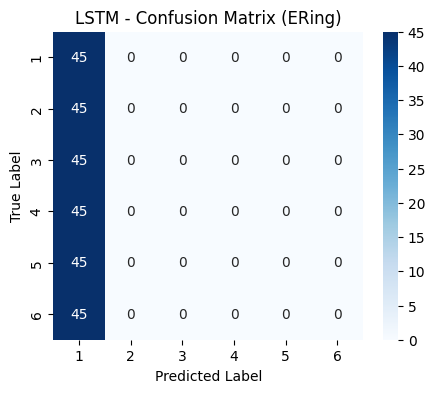

Training TST...


epoch,train_loss,valid_loss,accuracy,time
0,11.326612,9.644431,0.166667,00:01
1,10.932779,9.144563,0.166667,00:00
2,10.429495,8.048042,0.166667,00:00
3,9.734516,6.424554,0.166667,00:00
4,8.714668,4.624678,0.166667,00:00
5,7.694264,3.038097,0.166667,00:00
6,6.837243,1.860306,0.166667,00:00
7,6.186330,1.119816,0.166667,00:00
8,5.659336,0.813756,0.166667,00:00
9,5.183527,0.784512,0.166667,00:00


--- Đánh giá mô hình: Transformer ---
Accuracy : 0.1667
Precision: 0.0278
Recall   : 0.1667
F1-Score : 0.0476



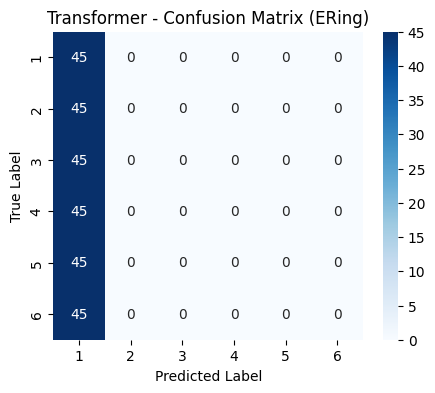

✅ Hoàn thành phân tích ERing. Kết quả đã lưu vào results/evaluation_metrics.csv


In [1]:
import pandas as pd
import numpy as np
import time
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from tsai.all import *
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from aeon.datasets import load_classification

# ==========================================
# 1. SETUP & LOAD DATA
# ==========================================
DATASET_NAME = "ERing"
print(f"--- Running Pipeline for {DATASET_NAME} ---")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Dùng aeon để tải tập Train và Test độc lập
X_train_ml, y_train_ml = load_classification(DATASET_NAME, split="train")
X_test_ml, y_test_ml = load_classification(DATASET_NAME, split="test")

# [SỬA LỖI Ở ĐÂY]: Mã hóa nhãn (String/Text) thành dạng số nguyên (Int) cho PyTorch
le = LabelEncoder()
y_train_ml = le.fit_transform(y_train_ml)
y_test_ml = le.transform(y_test_ml) # Chỉ transform trên test để tránh data leakage

# tsai cần toàn bộ X và y nằm chung 1 khối, sau đó dùng splits để cắt
X = np.concatenate((X_train_ml, X_test_ml), axis=0)
y = np.concatenate((y_train_ml, y_test_ml), axis=0)

# Tự tạo biến splits thủ công để thay thế biến splits bị lỗi của tsai
train_size = len(X_train_ml)
total_size = len(X)

train_idx = list(range(0, train_size))
test_idx = list(range(train_size, total_size))
splits = (train_idx, test_idx)

print(f"Đã tải thành công: Train ({len(train_idx)} mẫu), Test ({len(test_idx)} mẫu)")

# ==========================================
# 2. ENCAPSULATION: CÁC HÀM THUẬT TOÁN
# ==========================================

def run_knn_euclidean():
    print("Training standard k-NN (Euclidean)...")
    start_time = time.time()
    
    # K-NN cơ bản cần input 2D (Flatten)
    X_train_flat = X_train_ml.reshape(X_train_ml.shape[0], -1)
    X_test_flat = X_test_ml.reshape(X_test_ml.shape[0], -1)

    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train_flat, y_train_ml)
    
    preds = knn.predict(X_test_flat)
    return y_test_ml, preds, time.time() - start_time

def run_knn_dtw():
    print("Training k-NN with DTW...")
    start_time = time.time()
    
    knn_dtw = KNeighborsTimeSeriesClassifier(distance="dtw")
    knn_dtw.fit(X_train_ml, y_train_ml)
    
    preds = knn_dtw.predict(X_test_ml)
    return y_test_ml, preds, time.time() - start_time

def run_deep_learning_model(arch_name, epochs=30):
    print(f"Training {arch_name}...")
    start_time = time.time()
    model = TSClassifier(X, y, splits=splits, path='models',
                         arch=arch_name, 
                         metrics=accuracy, 
                         device=device,
                         verbose=False)
    
    # fit_one_cycle giúp giảm dần lr giúp hội tụ tốt hơn
    model.fit_one_cycle(epochs, 1e-3)
    
    preds_tensor, target_tensor = model.get_preds(ds_idx=1)
    
    preds = preds_tensor.argmax(dim=-1).numpy()
    target = target_tensor.numpy()
    
    return target, preds, time.time() - start_time

# ==========================================
# 3. ENCAPSULATION: HÀM ĐÁNH GIÁ (EVALUATION)
# ==========================================

def evaluate_and_log(y_true, y_pred, model_name, exec_time):
    print(f"--- Đánh giá mô hình: {model_name} ---")
    
    # Tính toán các chỉ số chuyên sâu
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")
    
    # [CẬP NHẬT Ở ĐÂY]: Giải mã nhãn số nguyên (0, 1) về lại văn bản gốc để biểu đồ dễ nhìn
    original_labels = le.inverse_transform(np.unique(y_true))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=original_labels, yticklabels=original_labels)
    plt.title(f"{model_name} - Confusion Matrix ({DATASET_NAME})")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Trả về dictionary để lưu CSV
    return {
        'Dataset': DATASET_NAME,
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1,
        'Time_sec': exec_time
    }

# ==========================================
# 4. THỰC THI PIPELINE VÀ LƯU KẾT QUẢ TỔNG HỢP
# ==========================================
all_results = []

# 1. k-NN (Euclidean)
y_true, y_pred, t_euc = run_knn_euclidean()
all_results.append(evaluate_and_log(y_true, y_pred, 'k-NN (Euc)', t_euc))

# 2. k-NN (DTW)
y_true, y_pred, t_dtw = run_knn_dtw()
all_results.append(evaluate_and_log(y_true, y_pred, 'k-NN (DTW)', t_dtw))

# 3. LSTM
y_true, y_pred, t_lstm = run_deep_learning_model("LSTM", epochs=30)
all_results.append(evaluate_and_log(y_true, y_pred, 'LSTM', t_lstm))

# 4. Transformer (TST)
y_true, y_pred, t_tst = run_deep_learning_model("TST", epochs=30)
all_results.append(evaluate_and_log(y_true, y_pred, 'Transformer', t_tst))

# Export ra CSV
df_results = pd.DataFrame(all_results)
csv_path = "results/evaluation_metrics.csv"
os.makedirs("results", exist_ok=True)

if not os.path.isfile(csv_path):
    df_results.to_csv(csv_path, index=False)
else:
    df_results.to_csv(csv_path, mode='a', header=False, index=False)

print(f"✅ Hoàn thành phân tích {DATASET_NAME}. Kết quả đã lưu vào {csv_path}")